---
title: "Лабораторна робота 1. Побудова простого лінійного бінарного класифікатора"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "09.03.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: реалізузвати найпростійший бінарний класифікатор засобами мови Python

## Завдання для самостійної роботи 

1. Імпортувати дані для навчальної вибірки згідно з індивідуальним варіантом (імпорт організувати з файлу).
1. Побудувати бінарний класифікатор і вивести результати бінарної класифікації на графіку.
1. Дати відповіді на контрольні запитання.
1. Відправити результати роботи у файлі lab_1_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

 Варіант 2:
 x_train_2:
 [[17 29]
  [44 12]
  [47  7]
  [18 17]
  [30 36]
  [ 6 10]
  [38  6]
  [10 38]
  [41 10]
  [42 10]];
 y_train_2:
 [ 1  1  1 -1  1  1 -1 -1  1 -1]

[np.float64(0.4), -1]


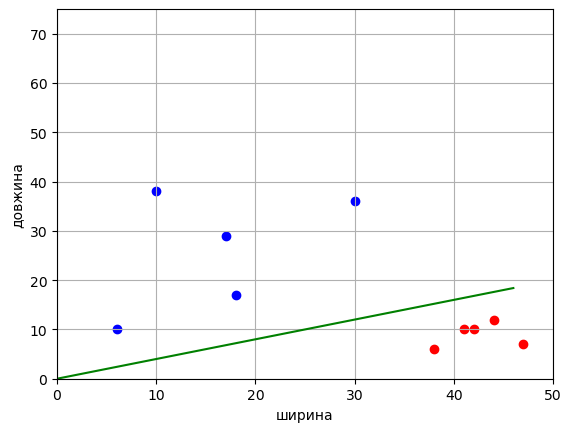

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]])
y_train = np.array([-1, 1, 1, -1, -1, -1, 1, -1, 1, 1])

n_train = len(x_train)                          # розмір навчальної вибірки
w = [0, -1]                                     # початкове значення вектора w
a = lambda x: np.sign(x[0]*w[0] + x[1]*w[1])    # правило класифікації
N = 50                                          # максимальна кількість ітерацій
L = 0.1                                         # крок зміни ваги
e = 0.1                                         # невелике додаток до w0, щоб забезпечити зазор між лінією розділення та областю

last_error_index = -1                           # індекс останньої помилкової спостереження

for n in range(N):
    for i in range(n_train):                # ітерація по спостереженням
        if y_train[i]*a(x_train[i]) < 0:    # якщо помилка класифікації,
            w[0] = w[0] + L * y_train[i]    # то коригування ваги w0
            last_error_index = i

    Q = sum([1 for i in range(n_train) if y_train[i]*a(x_train[i]) < 0])
    if Q == 0:      # показник якості класифікації (кількість помилок)
        break       # зупинка, якщо всі класифікуються правильно

if last_error_index > -1:
    w[0] = w[0] + e * y_train[last_error_index]

print(w)

line_x = list(range(max(x_train[:, 0])))    # створення графіка роздільної лінії
line_y = [w[0]*x for x in line_x]

x_0 = x_train[y_train == 1]                 # формування точок для 1-го
x_1 = x_train[y_train == -1]                # і 2-го класів

plt.scatter(x_0[:, 0], x_0[:, 1], color='red')
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')
plt.plot(line_x, line_y, color='green')

plt.xlim([0, 50])
plt.ylim([0, 75])
plt.ylabel("довжина")
plt.xlabel("ширина")
plt.grid(True)
plt.show()
